In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Model
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv("AbandonedPorn.csv")

# Preview
df.head()

,created_utc,score,domain,id,title,author,ups,downs,num_comments,permalink,selftext,link_flair_text,over_18,thumbnail,subreddit_id,edited,link_flair_css_class,author_flair_css_class,is_self,name,url,distinguished
0,1.353852e+09,3875,lh6.ggpht.com,13rck8,In a ghost town devoured by the Namibian Deser...,MacMorgan,6576,2701,107,http://www.reddit.com/r/AbandonedPorn/comments...,NaN,NaN,False,http://f.thumbs.redditmedia.com/1Ub0M0xtfVx0Ii...,t5_2sh6t,False,NaN,NaN,False,t3_13rck8,http://lh6.ggpht.com/-1Mp7aadKt6A/UE2BYWtbBzI/...,NaN
1,1.372700e+09,3133,i.imgur.com,1hfs7e,110 Year Old Ghost Ship - Ohio River Tributary...,jammich,8596,5463,344,http://www.reddit.com/r/AbandonedPorn/comments...,NaN,NaN,False,http://a.thumbs.redditmedia.com/9ZXQCTKDus5wRG...,t5_2sh6t,False,NaN,NaN,False,t3_1hfs7e,http://i.imgur.com/k2c0Lrm.jpg,NaN
2,1.361807e+09,2966,imgur.com,19726e,"Underwater statue of Jesus, Malta [640x425]",anticafard,5630,2664,155,http://www.reddit.com/r/AbandonedPorn/comments...,NaN,NaN,False,http://f.thumbs.redditmedia.com/OJ7xiQiqySdl1a...,t5_2sh6t,False,NaN,NaN,False,t3_19726e,http://imgur.com/onB8xbA,NaN
3,1.368655e+09,2955,i.imgur.com,1eeshv,"Deserted movie set used to film ""Big Fish"" [57...",tryintolaugh,6759,3804,236,http://www.reddit.com/r/AbandonedPorn/comments...,NaN,NaN,False,http://f.thumbs.redditmedia.com/_EDSOCmLyrri1Y...,t5_2sh6t,False,NaN,NaN,False,t3_1eeshv,http://i.imgur.com/ujzFTH3.jpg,NaN
4,1.374096e+09,2862,ianference.smugmug.com,1iihk1,Snow having fallen through a tiny hole in ceil...,Antiquarian23,5050,2188,88,http://www.reddit.com/r/AbandonedPorn/comments...,NaN,NaN,False,http://a.thumbs.redditmedia.com/YQypB1EzI1PhU3...,t5_2sh6t,False,NaN,Camera,False,t3_1iihk1,http://ianference.smugmug.com/Architecture/Asy...,NaN


In [3]:
print(df.shape)
print(df.info())
print(df.describe())

# Check missing values
print(df.isnull().sum())

(1000, 22)
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   created_utc             1000 non-null   float64
 1   score                   1000 non-null   int64  
 2   domain                  1000 non-null   str    
 3   id                      1000 non-null   str    
 4   title                   1000 non-null   str    
 5   author                  976 non-null    str    
 6   ups                     1000 non-null   int64  
 7   downs                   1000 non-null   int64  
 8   num_comments            1000 non-null   int64  
 9   permalink               1000 non-null   str    
 10  selftext                0 non-null      float64
 11  link_flair_text         0 non-null      float64
 12  over_18                 1000 non-null   bool   
 13  thumbnail               1000 non-null   str    
 14  subreddit_id            1000 non-null   s

In [5]:
# Drop duplicates
df = df.drop_duplicates()

# Fill missing values (forward fill)
df = df.ffill()

In [7]:
df.columns = df.columns.str.strip()

In [9]:
from sklearn.model_selection import train_test_split

# Example dataset
from sklearn.datasets import load_iris
data = load_iris()

X = data.data      # features
y = data.target    # labels

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [12]:
y_pred = model.predict(X_test)

Accuracy: 1.0


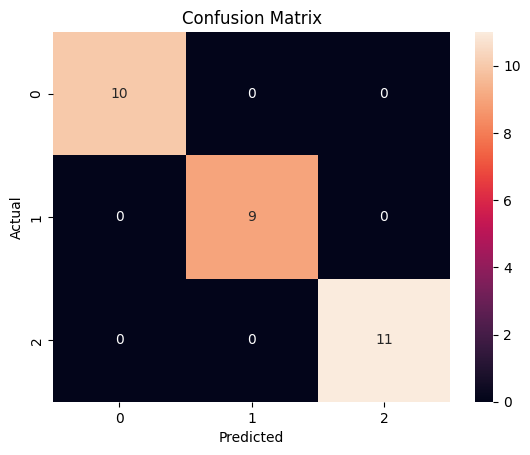

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [13]:
# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print(classification_report(y_test, y_pred))